<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-02/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab02 - ML - Assignment


BL.SC.U4CSE24070 - Tabrej Ansari


CSE - A

# Mandatory Questions

A1 & A2: Purchase Data Analysis and Customer Classification

In [2]:

from google.colab import files

uploaded = files.upload()

Saving Lab Session Data.xlsx to Lab Session Data.xlsx


In [3]:
#A1 & A2

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



# Function to load purchase data
def load_purchase_data(file_path):
    data = pd.read_excel(file_path, sheet_name="Purchase data")
    return data



# Create Feature Matrix X and Output Vector y
def create_feature_output(data):

    X = data[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]].to_numpy()

    y = data["Payment (Rs)"].to_numpy()

    return X, y


# Matrix Properties
def matrix_properties(X):

    dimension = X.shape[1]
    number_of_vectors = X.shape[0]
    rank = np.linalg.matrix_rank(X)

    return dimension, number_of_vectors, rank


# Find Cost of Each Product
def calculate_product_costs(X, y):

    pseudo_inverse = np.linalg.pinv(X)

    costs = pseudo_inverse @ y

    return costs



# Create Rich/Poor Labels
def create_labels(y):

    labels = np.where(y > 200, "RICH", "POOR")

    return labels



# Encode Labels
def encode_labels(labels):

    encoded = np.where(labels == "RICH", 1, 0)

    return encoded



# Train Decision Tree Classifier
def train_classifier(X, encoded_labels):

    classifier = DecisionTreeClassifier(random_state=42)

    classifier.fit(X, encoded_labels)

    return classifier



# Predict Labels
def predict_labels(classifier, X):

    predictions = classifier.predict(X)

    return predictions


# Accuracy
def calculate_accuracy(actual, predicted):

    return accuracy_score(actual, predicted)



# Main Function
def main():

    file_path = "Lab Session Data.xlsx"

    purchase_data = load_purchase_data(file_path)

    X, y = create_feature_output(purchase_data)

    dimension, vectors, rank = matrix_properties(X)

    product_costs = calculate_product_costs(X, y)

    labels = create_labels(y)

    encoded_labels = encode_labels(labels)

    classifier = train_classifier(X, encoded_labels)

    predictions = predict_labels(classifier, X)

    accuracy = calculate_accuracy(encoded_labels, predictions)

    #  Printing
    print("\n========== A1 ==========\n")

    print("Feature Matrix (X):\n")
    print(X)

    print("\nOutput Vector (y):\n")
    print(y)

    print("\nDimension of Vector Space :", dimension)

    print("Number of Vectors :", vectors)

    print("Rank of Feature Matrix :", rank)

    print("\nEstimated Cost of Products")

    print("-----------------------------------")
    print("Candy Cost        : {:.2f}".format(product_costs[0]))
    print("Mango Cost (Kg)   : {:.2f}".format(product_costs[1]))
    print("Milk Packet Cost  : {:.2f}".format(product_costs[2]))
    print("-----------------------------------")

    print("\n========== A2 ==========\n")

    purchase_data["Class"] = labels

    print(purchase_data[["Customer", "Payment (Rs)", "Class"]])

    print("\nPredicted Labels")

    predicted_class = np.where(predictions == 1, "RICH", "POOR")

    print(predicted_class)

    print("\nClassifier Accuracy : {:.2f}%".format(accuracy * 100))


if __name__ == "__main__":
    main()


========== A1 ==========

Feature Matrix (X):

[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]

Output Vector (y):

[386 289 393 110 280 167 271 274 148 198]

Dimension of Vector Space : 3
Number of Vectors : 10
Rank of Feature Matrix : 3

Estimated Cost of Products
-----------------------------------
Candy Cost        : 1.00
Mango Cost (Kg)   : 55.00
Milk Packet Cost  : 18.00
-----------------------------------

========== A2 ==========

  Customer  Payment (Rs) Class
0      C_1           386  RICH
1      C_2           289  RICH
2      C_3           393  RICH
3      C_4           110  POOR
4      C_5           280  RICH
5      C_6           167  POOR
6      C_7           271  RICH
7      C_8           274  RICH
8      C_9           148  POOR
9     C_10           198  POOR

Predicted Labels
['RICH' 'RICH' 'RICH' 'POOR' 'RICH' 'POOR' 'RICH' 'RICH' 'POOR' 'POOR']

Classifier Accuracy : 100.00%


In [4]:
import pandas as pd

data = pd.read_excel("Lab Session Data.xlsx", sheet_name="IRCTC Stock Price")

print(data.columns)

Index(['Date', 'Month', 'Day', 'Price', 'Open', 'High', 'Low', 'Volume',
       'Chg%'],
      dtype='object')


A3. Statistical Analysis of IRCTC Stock Price Data

Saving Lab Session Data.xlsx to Lab Session Data (1).xlsx
========== A3 ==========

Population Mean = 1560.6634538152612
Population Variance = 58496.49239931618

Custom Mean = 1560.6634538152598
Custom Variance = 58496.49239931618

Average Time (NumPy Mean) = 4.884699983449536e-05
Average Time (Custom Mean) = 5.2656800016848136e-05

Average Time (NumPy Variance) = 3.330729996378068e-05
Average Time (Custom Variance) = 0.000144063300012931

Wednesday Mean = 1550.7060000000001
April Mean = 1698.9526315789474

Probability of Loss = 0.4979919678714859
Probability of Profit on Wednesday = 0.42
Conditional Probability of Profit given Wednesday = 0.42


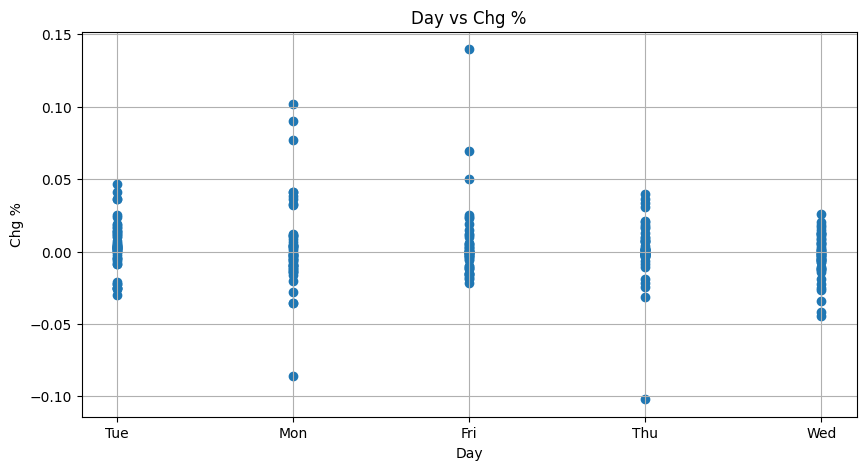

In [6]:
#A3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files

# Upload Excel File
uploaded = files.upload()
file_path = list(uploaded.keys())[0]


# Load Data
def load_data(path):
    return pd.read_excel(path, sheet_name="IRCTC Stock Price")


# NumPy Mean
def numpy_mean(price):
    return np.mean(price)


# NumPy Variance
def numpy_variance(price):
    return np.var(price)


# Custom Mean
def custom_mean(price):
    total = 0

    for value in price:
        total += value

    return total / len(price)


# Custom Variance
def custom_variance(price):

    mean = custom_mean(price)

    total = 0

    for value in price:
        total += (value - mean) ** 2

    return total / len(price)


# Average Execution Time
def average_execution_time(function_name, data):

    total = 0

    for i in range(10):

        start = time.perf_counter()

        function_name(data)

        end = time.perf_counter()

        total += end - start

    return total / 10


# Wednesday Mean
def wednesday_mean(df):

    wed = df[df["Day"] == "Wed"]

    return np.mean(wed["Price"])


# April Mean
def april_mean(df):

    april = df[df["Month"] == "Apr"]

    return np.mean(april["Price"])


# Probability of Loss
def probability_of_loss(df):

    total = len(df)

    loss = len(df[df["Chg%"] < 0])

    return loss / total


# Probability of Profit on Wednesday
def probability_profit_wednesday(df):

    wed = df[df["Day"] == "Wed"]

    if len(wed) == 0:
        return 0

    profit = len(wed[wed["Chg%"] > 0])

    return profit / len(wed)


# Conditional Probability
def conditional_probability(df):

    wed = df[df["Day"] == "Wed"]

    if len(wed) == 0:
        return 0

    profit = len(wed[wed["Chg%"] > 0])

    return profit / len(wed)


# Scatter Plot
def scatter_plot(df):

    plt.figure(figsize=(10,5))

    plt.scatter(df["Day"], df["Chg%"])

    plt.xlabel("Day")

    plt.ylabel("Chg %")

    plt.title("Day vs Chg %")

    plt.grid(True)

    plt.show()


# ---------------- Main ----------------
def main():

    data = load_data(file_path)

    price = data["Price"]

    print("========== A3 ==========\n")

    print("Population Mean =", numpy_mean(price))

    print("Population Variance =", numpy_variance(price))

    print()

    print("Custom Mean =", custom_mean(price))

    print("Custom Variance =", custom_variance(price))

    print()

    print("Average Time (NumPy Mean) =", average_execution_time(numpy_mean, price))

    print("Average Time (Custom Mean) =", average_execution_time(custom_mean, price))

    print()

    print("Average Time (NumPy Variance) =", average_execution_time(numpy_variance, price))

    print("Average Time (Custom Variance) =", average_execution_time(custom_variance, price))

    print()

    print("Wednesday Mean =", wednesday_mean(data))

    print("April Mean =", april_mean(data))

    print()

    print("Probability of Loss =", probability_of_loss(data))

    print("Probability of Profit on Wednesday =", probability_profit_wednesday(data))

    print("Conditional Probability of Profit given Wednesday =",
          conditional_probability(data))

    scatter_plot(data)


if __name__ == "__main__":
    main()

A4. Exploratory Data Analysis of Thyroid Dataset

In [7]:
#A4

import pandas as pd
import numpy as np

# Load Thyroid Dataset
def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI")


# Data Types
def attribute_information(df):

    info = []

    for column in df.columns:

        dtype = df[column].dtype

        if dtype == "object":
            datatype = "Categorical (Nominal)"
            encoding = "One-Hot Encoding"
        else:
            datatype = "Numeric"
            encoding = "Not Required"

        info.append([column, datatype, encoding])

    return pd.DataFrame(info,
                        columns=["Attribute",
                                 "Datatype",
                                 "Suggested Encoding"])


# Numeric Summary
def numeric_summary(df):

    numeric = df.select_dtypes(include=np.number)

    summary = pd.DataFrame({
        "Minimum": numeric.min(),
        "Maximum": numeric.max(),
        "Mean": numeric.mean(),
        "Variance": numeric.var()
    })

    return summary



# Missing Values
def missing_values(df):

    temp = df.replace("?", np.nan)

    return temp.isnull().sum()


# Outliers using IQR
def outliers(df):

    numeric = df.select_dtypes(include=np.number)

    result = {}

    for column in numeric.columns:

        Q1 = numeric[column].quantile(0.25)
        Q3 = numeric[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = ((numeric[column] < lower) |
                 (numeric[column] > upper)).sum()

        result[column] = count

    return result



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    thyroid = load_data(file_path)

    print("\n===== First Five Rows =====\n")
    print(thyroid.head())

    print("\n===== Dataset Shape =====")
    print(thyroid.shape)

    print("\n===== Attribute Information =====\n")
    print(attribute_information(thyroid))

    print("\n===== Numeric Summary =====\n")
    print(numeric_summary(thyroid))

    print("\n===== Missing Values =====\n")
    print(missing_values(thyroid))

    print("\n===== Outliers =====\n")
    print(outliers(thyroid))


if __name__ == "__main__":
    main()


===== First Five Rows =====

   Record ID  age sex on thyroxine query on thyroxine  \
0  840801013   29   F            f                  f   
1  840801014   29   F            f                  f   
2  840801042   41   F            f                  f   
3  840803046   36   F            f                  f   
4  840803047   32   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured  TT4 T4U measured T4U FTI measured FTI TBG measured TBG  \
0            f    ?            f   ?            f   ?            f

/tmp/ipykernel_634/4036970599.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp = df.replace("?", np.nan)


A5. Similarity Measurement Using Binary Attributes

In [8]:
#A5

import pandas as pd
import numpy as np


# Load Dataset
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="thyroid0387_UCI")



# Convert Binary Attributes
def binary_columns(df):

    temp = df.replace({"t":1,
                       "f":0,
                       "M":1,
                       "F":0,
                       "?":np.nan})

    binary = []

    for column in temp.columns:

        values = temp[column].dropna().unique()

        if set(values).issubset({0,1}):

            binary.append(column)

    return temp[binary]



# Jaccard
def jaccard(v1,v2):

    f11 = 0
    f10 = 0
    f01 = 0

    for a,b in zip(v1,v2):

        if a==1 and b==1:
            f11+=1

        elif a==1 and b==0:
            f10+=1

        elif a==0 and b==1:
            f01+=1

    return f11/(f11+f10+f01)



# SMC
def smc(v1,v2):

    f11=0
    f10=0
    f01=0
    f00=0

    for a,b in zip(v1,v2):

        if a==1 and b==1:
            f11+=1

        elif a==1 and b==0:
            f10+=1

        elif a==0 and b==1:
            f01+=1

        else:
            f00+=1

    return (f11+f00)/(f11+f10+f01+f00)



# Main
def main():

    file_path="Lab Session Data.xlsx"

    data=load_data(file_path)

    binary=binary_columns(data)

    binary=binary.fillna(0)

    vector1=binary.iloc[0].astype(int).values

    vector2=binary.iloc[1].astype(int).values

    jc=jaccard(vector1,vector2)

    smc_value=smc(vector1,vector2)

    print("Binary Columns\n")
    print(binary.columns.tolist())

    print("\nJaccard Coefficient =",jc)

    print("Simple Matching Coefficient =",smc_value)


if __name__=="__main__":
    main()

Binary Columns

['sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']

Jaccard Coefficient = 0.25
Simple Matching Coefficient = 0.8571428571428571


/tmp/ipykernel_634/3272049137.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp = df.replace({"t":1,


A6. Cosine Similarity Measurement

In [9]:
#A6

import pandas as pd
import numpy as np



# Load Dataset
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="thyroid0387_UCI")



# Preprocess Dataset
def preprocess(df):

    # Convert categorical values into numeric values
    df = df.replace({
        "t": 1,
        "f": 0,
        "M": 1,
        "F": 0,
        "?": np.nan
    })

    # Convert every column to numeric where possible
    df = df.apply(pd.to_numeric, errors="coerce")

    # Replace missing values with 0
    df = df.fillna(0)

    return df


# Cosine Similarity
def cosine_similarity(vector1, vector2):

    dot_product = np.dot(vector1, vector2)

    magnitude1 = np.linalg.norm(vector1)

    magnitude2 = np.linalg.norm(vector2)

    similarity = dot_product / (magnitude1 * magnitude2)

    return similarity



# Main Function
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    data = preprocess(data)

    # First two observation vectors
    vector1 = data.iloc[0].values
    vector2 = data.iloc[1].values

    similarity = cosine_similarity(vector1, vector2)

    print("========== A6 ==========\n")

    print("First Observation Vector:\n")
    print(vector1)

    print("\nSecond Observation Vector:\n")
    print(vector2)

    print("\nCosine Similarity =", similarity)


if __name__ == "__main__":
    main()

========== A6 ==========

First Observation Vector:

[8.40801013e+08 2.90000000e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 3.00000000e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Second Observation Vector:

[8.40801014e+08 2.90000000e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.60000000e+00 1.00000000e+00
 1.90000000e+00 1.00000000e+00 1.28000000e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0

/tmp/ipykernel_634/4292963273.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


A7. Heatmap Visualization of Similarity Measures

/tmp/ipykernel_634/2716823983.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({


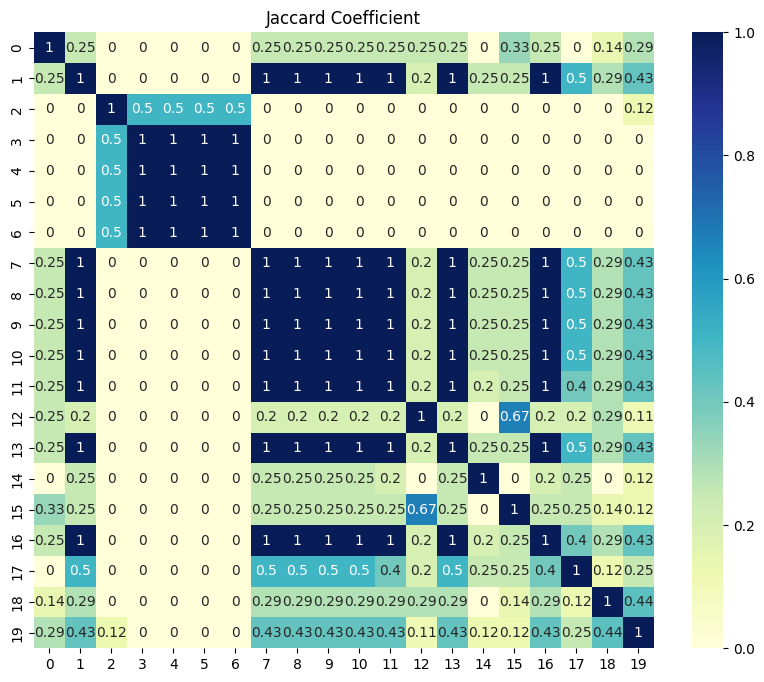

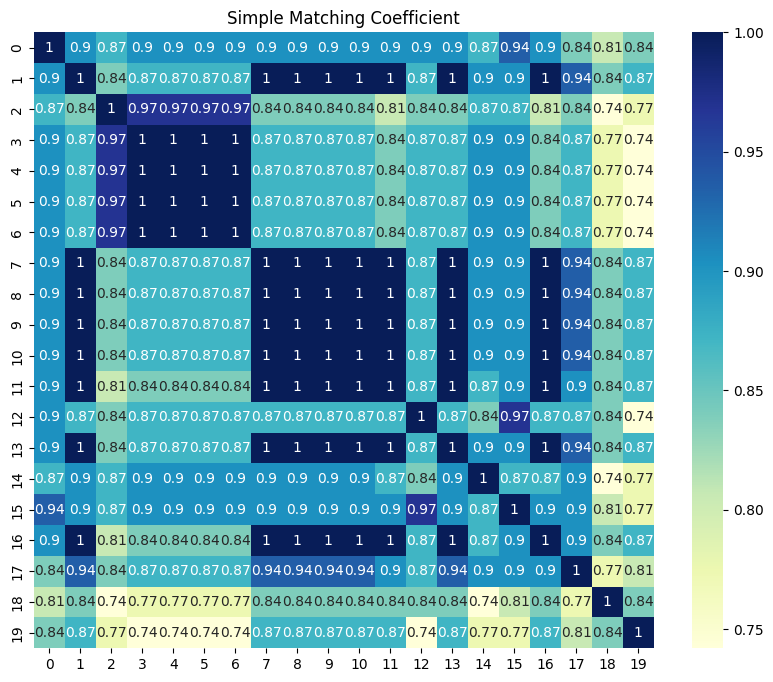

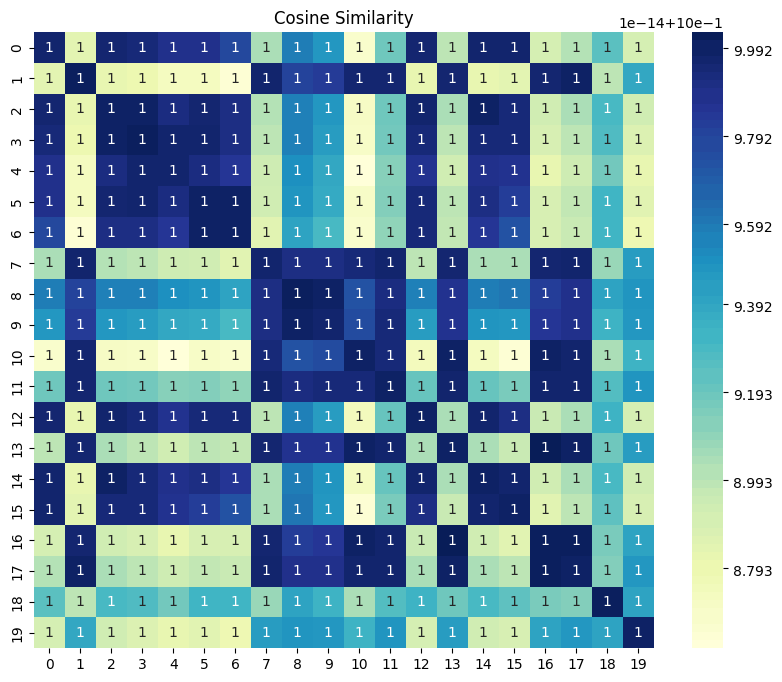

In [10]:
# A7 Heatmap Plot

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Load Dataset
def load_data(file_path):

    data = pd.read_excel(file_path, sheet_name="thyroid0387_UCI")

    return data



# Preprocess Dataset
def preprocess(data):

    data = data.replace({
        "t": 1,
        "f": 0,
        "M": 1,
        "F": 0,
        "?": np.nan
    })

    data = data.apply(pd.to_numeric, errors="coerce")

    data = data.fillna(0)

    return data


# Jaccard
def jaccard(v1, v2):

    f11 = f10 = f01 = 0

    for a, b in zip(v1, v2):

        if a == 1 and b == 1:
            f11 += 1

        elif a == 1 and b == 0:
            f10 += 1

        elif a == 0 and b == 1:
            f01 += 1

    if (f11 + f10 + f01) == 0:
        return 0

    return f11 / (f11 + f10 + f01)


# SMC
def smc(v1, v2):

    f11 = f10 = f01 = f00 = 0

    for a, b in zip(v1, v2):

        if a == 1 and b == 1:
            f11 += 1

        elif a == 1 and b == 0:
            f10 += 1

        elif a == 0 and b == 1:
            f01 += 1

        else:
            f00 += 1

    return (f11 + f00) / (f11 + f10 + f01 + f00)



# Cosine Similarity
def cosine(v1, v2):

    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))



# Similarity Matrix
def similarity_matrix(data, method):

    n = len(data)

    matrix = np.zeros((n, n))

    for i in range(n):

        for j in range(n):

            if method == "JC":
                matrix[i][j] = jaccard(data.iloc[i], data.iloc[j])

            elif method == "SMC":
                matrix[i][j] = smc(data.iloc[i], data.iloc[j])

            else:
                matrix[i][j] = cosine(data.iloc[i], data.iloc[j])

    return matrix


# Heatmap
def draw_heatmap(matrix, title):

    plt.figure(figsize=(10,8))

    sns.heatmap(matrix,
                annot=True,
                cmap="YlGnBu")

    plt.title(title)

    plt.show()



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    data = preprocess(data)

    data = data.iloc[:20]

    jc = similarity_matrix(data, "JC")

    smc_matrix = similarity_matrix(data, "SMC")

    cos = similarity_matrix(data, "COS")

    draw_heatmap(jc, "Jaccard Coefficient")

    draw_heatmap(smc_matrix, "Simple Matching Coefficient")

    draw_heatmap(cos, "Cosine Similarity")


if __name__ == "__main__":
    main()

A8 Data Imputation

In [11]:
#A8

import pandas as pd
import numpy as np


# Load Dataset
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="thyroid0387_UCI")


# Missing Value Treatment
def impute_data(df):

    df = df.replace("?", np.nan)

    numeric = df.select_dtypes(include=np.number).columns

    categorical = df.select_dtypes(exclude=np.number).columns

    # Numeric Columns
    for column in numeric:

        q1 = df[column].quantile(0.25)

        q3 = df[column].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr

        upper = q3 + 1.5 * iqr

        outlier = ((df[column] < lower) |
                   (df[column] > upper)).sum()

        if outlier == 0:

            df[column].fillna(df[column].mean(),
                              inplace=True)

        else:

            df[column].fillna(df[column].median(),
                              inplace=True)

    # Categorical Columns
    for column in categorical:

        df[column].fillna(df[column].mode()[0],
                          inplace=True)

    return df



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    data = impute_data(data)

    print(data.head())

    print()

    print(data.isnull().sum())


if __name__ == "__main__":
    main()

   Record ID  age sex on thyroxine query on thyroxine  \
0  840801013   29   F            f                  f   
1  840801014   29   F            f                  f   
2  840801042   41   F            f                  f   
3  840803046   36   F            f                  f   
4  840803047   32   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured    TT4 T4U measured   T4U FTI measured    FTI TBG measured  \
0            f  104.0            f  0.96            f  109.0            f   
1            t  

/tmp/ipykernel_634/2630959714.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("?", np.nan)
/tmp/ipykernel_634/2630959714.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(),
/tmp/ipykernel_634/2630959714.py:46: FutureWarning: A value is tryin

A9 Data Normalization

In [12]:
# A9

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler



# Load Dataset
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="thyroid0387_UCI")



# Normalize Dataset
def normalize(df):

    numeric = df.select_dtypes(include=np.number)

    scaler = MinMaxScaler()

    normalized = scaler.fit_transform(numeric)

    normalized = pd.DataFrame(normalized,
                              columns=numeric.columns)

    return normalized



# Standardize Dataset
def standardize(df):

    numeric = df.select_dtypes(include=np.number)

    scaler = StandardScaler()

    standardized = scaler.fit_transform(numeric)

    standardized = pd.DataFrame(standardized,
                                columns=numeric.columns)

    return standardized



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    normalized = normalize(data)

    standardized = standardize(data)

    print("Normalized Data\n")

    print(normalized.head())

    print()

    print("Standardized Data\n")

    print(standardized.head())


if __name__ == "__main__":
    main()

Normalized Data

      Record ID       age
0  0.000000e+00  0.000427
1  3.410871e-08  0.000427
2  9.891527e-07  0.000610
3  6.934301e-05  0.000534
4  6.937712e-05  0.000473

Standardized Data

   Record ID       age
0  -1.602090 -0.037634
1  -1.602090 -0.037634
2  -1.602086 -0.027499
3  -1.601822 -0.031722
4  -1.601822 -0.035100


# Optional Questions

O1: Square Matrices from Purchase Data

In [13]:
# O1:

import pandas as pd
import numpy as np



# Load Purchase Data
def load_purchase(file_path):

    return pd.read_excel(file_path,
                         sheet_name="Purchase data")



# Product Cost
def calculate_cost(X, y):

    return np.linalg.pinv(X) @ y



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_purchase(file_path)

    X = data[["Candies (#)",
              "Mangoes (Kg)",
              "Milk Packets (#)"]].values

    y = data["Payment (Rs)"].values

    # Complete Dataset
    full_cost = calculate_cost(X, y)

    # First 3 observations
    X1 = X[:3]
    y1 = y[:3]

    # Next 3 observations
    X2 = X[3:6]
    y2 = y[3:6]

    cost1 = calculate_cost(X1, y1)
    cost2 = calculate_cost(X2, y2)

    print("Complete Dataset Cost")

    print(full_cost)

    print()

    print("Square Matrix 1 Cost")

    print(cost1)

    print()

    print("Square Matrix 2 Cost")

    print(cost2)

    print()

    print("Comparison")

    print("Square matrices may not exactly match the full dataset because they use fewer observations.")


if __name__ == "__main__":
    main()

Complete Dataset Cost
[ 1. 55. 18.]

Square Matrix 1 Cost
[ 1. 55. 18.]

Square Matrix 2 Cost
[ 1. 55. 18.]

Comparison
Square matrices may not exactly match the full dataset because they use fewer observations.


O2: Random Sampling (A4–A6)

In [14]:
# O2

import pandas as pd
import numpy as np



# Load Data
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="thyroid0387_UCI")



# Random Sample
def random_sample(df):

    return df.sample(n=20,
                     random_state=42)



# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    sample = random_sample(data)

    print(sample)


if __name__ == "__main__":
    main()


      Record ID  age sex on thyroxine query on thyroxine  \
624   841003032   72   M            f                  f   
6458  860408064   57   F            f                  f   
3128  850612010   82   M            f                  f   
5501  851217005   58   F            f                  f   
9070  870109043   80   M            f                  f   
3298  850626022   28   M            f                  f   
2664  850507059   78   F            f                  f   
5810  860217001   29   F            f                  f   
5504  851217008   82   M            f                  f   
5274  851128092   20   F            f                  f   
8670  861128023   33   F            f                  f   
4192  850904060   87   F            f                  f   
5924  860225003   60   F            f                  f   
4721  851017029   76   F            f                  f   
8604  861121057   64   F            f                  f   
7361  860818016   56   M            f   

O3: Marketing Campaign Dataset


In [15]:
# O3

import pandas as pd
import numpy as np



# Load Dataset
def load_data(file_path):

    return pd.read_excel(file_path,
                         sheet_name="marketing_campaign")


# Missing Values
def missing(df):

    return df.isnull().sum()


# Summary
def summary(df):

    return df.describe(include="all")


# Main
def main():

    file_path = "Lab Session Data.xlsx"

    data = load_data(file_path)

    print("Shape")

    print(data.shape)

    print()

    print("Columns")

    print(data.columns)

    print()

    print("Data Types")

    print(data.dtypes)

    print()

    print("Missing Values")

    print(missing(data))

    print()

    print("Summary")

    print(summary(data))


if __name__ == "__main__":
    main()

Shape
(2240, 29)

Columns
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

Data Types
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldP